# 26. LR·SVM·MERT 고정 설정 전이

Main 실험에서 고른 LR `C=0.01`, SVM `C=10, gamma=0.001`, MERT `layer=4, C=0.01`을 고정했다. MusicGen·Udio를 각각 Train·Validation에서 제외해 새 가중치를 학습하고, 해당 Validation에서 임계값을 정한 기존 실행이다. 원래 Test의 REAL 45곡과 대상 FAKE만 평가했다. 설정 선택에는 두 대상이 포함된 과거 Validation이 쓰였으므로 완전 미노출 실험은 아니다.

In [1]:
# Main 설정을 고정한 여섯 fresh fit의 산출물과 run ID를 읽는다.
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
RUN_ID = "unseen_fixed_classical_mert_20260919T173138Z"
RESULT = ROOT / "results/unseen_fixed_transfer_classical_mert" / RUN_ID
sha256 = lambda path: hashlib.sha256(Path(path).read_bytes()).hexdigest()
selected = json.loads((RESULT / "fixed_selections.json").read_text(encoding="utf-8"))
meta = json.loads((RESULT / "run_metadata.json").read_text(encoding="utf-8"))
inclusion = pd.read_csv(RESULT / "inclusion_counts.csv")
cohorts = pd.read_csv(RESULT / "test_cohorts.csv")
primary = pd.read_csv(RESULT / "primary_test_metrics.csv")
paired = pd.read_csv(RESULT / "paired_source_test_metrics.csv")
assert selected["run_id"] == meta["run_id"] == RUN_ID
assert selected["variant"] == "fixed_hyperparameter_transfer"
print("run_id:", RUN_ID, "· six freshly trained fixed models")

run_id: unseen_fixed_classical_mert_20260919T173138Z · six freshly trained fixed models


## 1. 설정·프로토콜 동결

Main 선택 JSON과 저장된 원본 checkpoint를 확인한 후 동일 하이퍼파라미터만 사용했다. 이번 run은 원본 checkpoint의 **가중치를 이어 학습하지 않았다**. 아래 원본 설정 파일·가중치 SHA와 이번 체크포인트 SHA, 새 프로토콜 SHA가 재현 경로를 고정한다.

In [2]:
# 고정 프로토콜·Main 설정 출처·새 checkpoint hash를 Test 표 해석 전에 검증한다.
assert (
    sha256(ROOT / "docs/UNSEEN_FIXED_PROTOCOL.md")
    == selected["protocol_sha256"]
    == meta["protocol_sha256"]
)
assert (
    selected["protocol_sha256"]
    == "098fa65192f65fddbf7d65757eb5c6b5c2b1149f79178c27746b4e328ee54a5e"
)
assert sha256(RESULT / "fixed_selections.json") == meta["fixed_selections_sha256"]
assert meta["hyperparameters_reselected_on_filtered_val"] is False
assert meta["thresholds_selected_on_filtered_val"] is True
assert (
    sha256(ROOT / "results/model_tuning/classical_best_configs.json")
    == selected["source_config_sha256"]["classical"]
)
assert (
    sha256(
        ROOT / "results/model_tuning/mert_best_config_mert_binary_20260919T110741Z.json"
    )
    == selected["source_config_sha256"]["mert"]
)
checkpoint_rows = []
for target, models in selected["selected"].items():
    for model, choice in models.items():
        assert sha256(choice["checkpoint"]) == choice["checkpoint_sha256"]
        checkpoint_rows.append(
            {
                "holdout": target,
                "model": model,
                "new_checkpoint_sha256": choice["checkpoint_sha256"],
            }
        )
print("fixed protocol SHA-256:", selected["protocol_sha256"])
print("frozen selection JSON SHA-256:", meta["fixed_selections_sha256"])
print("main source runs:", selected["source_runs"])
print("main source checkpoint SHA-256:", selected["source_checkpoint_sha256"])
display(pd.DataFrame(checkpoint_rows))

fixed protocol SHA-256: 098fa65192f65fddbf7d65757eb5c6b5c2b1149f79178c27746b4e328ee54a5e
frozen selection JSON SHA-256: c4c73cffd7d2134bfb6feca5ba34950f726df554ecdbec77126b49c110da6a56
main source runs: {'classical': 'classical_20260919T110356Z', 'mert': 'mert_binary_20260919T110741Z'}
main source checkpoint SHA-256: {'LogisticRegression': 'cbfe44d6bcdf323482de2298846d96fc5959837b006321521786770b0a435440', 'RBF-SVM': '6ca27b6bfa5b5197f8a08fede590ebc2c08f518d6312c8922ad420fb2d03e628', 'Frozen MERT + LR': '93459ef73dd021270d74566776d7fbf865d93ef5af9fb43e77b44b6afe0e9164'}


,holdout,model,new_checkpoint_sha256
0,musicgen,LogisticRegression,af2326ba5fcc101a22a9f44cdbfb666d9cbef8fa6f35f7...
1,musicgen,RBF-SVM,f164be8a7d2071322f02cbd34c4f6398ab3739c5655ade...
2,musicgen,Frozen MERT + LR,16e4090e92643d84106a352f373e3209251d7a315e2b13...
3,udio,LogisticRegression,f2e29f30611a9a52c25809ad5b9fcaa076b95d855147d3...
4,udio,RBF-SVM,c47bf13f8b89fb67de17b77ec442367b5214f75225585f...
5,udio,Frozen MERT + LR,507abed5820936c37cdb8122de08bcd145aedab21eb970...


새 primary 프로토콜 SHA-256은 `098fa65192f65fddbf7d65757eb5c6b5c2b1149f79178c27746b4e328ee54a5e`였다. Main 설정 파일·원본 checkpoint 해시와 새 6개 checkpoint 해시가 저장 기록과 일치했다.

새 모델은 Main의 고정 설정을 출처까지 확인하고 각 대상용 가중치를 따로 저장했다.

Main 설정 자체는 MusicGen/Udio가 포함된 Validation에서 선택됐으므로 완전히 미노출인 하이퍼파라미터 선택이 아니다.

## 2. 필터된 Train/Validation과 원래 Test cohort

두 실험 모두 Train/Validation의 대상 FAKE만 제외했다. Primary Test의 MusicGen은 REAL 45·FAKE 45 Track(270 Segment), Udio는 REAL 45·FAKE 48 Track(279 Segment)이다. Udio FAKE는 원곡 24개에서만 생성됐고 REAL 45개 중 21개는 짝이 없다.

In [3]:
# MusicGen/Udio FAKE가 각각 Train/Validation에서 제거됐는지 재확인한다.
manifest = pd.read_csv(ROOT / "data/metadata/segment_manifest_10s.csv")
for target in ("musicgen", "udio"):
    for split in ("train", "val"):
        filtered = manifest.loc[
            manifest.split.eq(split)
            & (manifest.label_id.eq(0) | manifest.generator.ne(target))
        ]
        # ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
        assert not filtered.loc[filtered.label_id.eq(1), "generator"].eq(target).any()
    expected = manifest.loc[
        manifest.split.eq("test")
        & (manifest.label_id.eq(0) | manifest.generator.eq(target))
    ]
    cohort = cohorts.loc[cohorts.holdout_generator.eq(target)].iloc[0]
    assert len(expected) == cohort["primary_segments"]
    assert (
        expected.loc[expected.label_id.eq(0), "track_sample_id"].nunique()
        == cohort["primary_real_tracks"]
    )
    assert (
        expected.loc[expected.label_id.eq(1), "track_sample_id"].nunique()
        == cohort["primary_fake_tracks"]
    )
print("Filtered Train/Validation:")
display(
    inclusion[
        ["holdout_generator", "split", "label", "original_audio", "tracks", "segments"]
    ]
)
print("Fixed primary Test and paired-source subset:")
display(cohorts.drop(columns="run_id"))

Filtered Train/Validation:


,holdout_generator,split,label,original_audio,tracks,segments
0,musicgen,train,REAL,207,207,621
1,musicgen,train,FAKE,206,1980,5731
2,musicgen,val,REAL,44,44,132
3,musicgen,val,FAKE,44,440,1277
4,udio,train,REAL,207,207,621
5,udio,train,FAKE,207,1981,5734
6,udio,val,REAL,44,44,132
7,udio,val,FAKE,44,435,1262


Fixed primary Test and paired-source subset:


,holdout_generator,primary_real_tracks,primary_fake_tracks,primary_fake_original_audio,primary_segments,paired_real_tracks,paired_fake_tracks
0,musicgen,45,45,45,270,45,45
1,udio,45,48,24,279,24,48


MusicGen 제외 Train/Validation의 REAL·FAKE Segment 수는 각각 621/5,731과 132/1,277이었다. Udio 제외 수는 621/5,734와 132/1,262였다. Primary Test는 MusicGen REAL45/FAKE45 Track(270 Segment), Udio REAL45/FAKE48 Track(279 Segment)이다.

원래 group split 안에서 대상 FAKE만 학습·임계값 선택에서 제외했다.

Train/Validation은 FAKE가 크게 우세하고 Udio FAKE는 24개 원곡에서만 나왔다. REAL Test는 45 Track으로 작다.

## 3. 필터된 Validation에서 정한 임계값

LR·SVM·MERT 설정은 위 Main 값에서 변경하지 않았다. 분류 임계값만 대상별로, 그리고 Segment·Track별로 별도 선택했다. SVM 점수와 임계값은 FAKE 방향 decision margin이고 LR·MERT는 FAKE 확률이다.

In [4]:
# 모델 설정 재탐색 없이 필터된 Validation으로 고른 임계값을 표시한다.
rows = []
for target, models in selected["selected"].items():
    for model, choice in models.items():
        rows.append(
            {
                "holdout": target,
                "model": model,
                "fixed_config": selected["main_best"][model],
                "Val Track AUC": choice["val_track"]["roc_auc"],
                "Val Track EER": choice["val_track"]["eer"],
                "Val Segment threshold": choice["thresholds"]["segment"],
                "Val Track threshold": choice["thresholds"]["track"],
            }
        )
display(pd.DataFrame(rows).round(4))

,holdout,model,fixed_config,Val Track AUC,Val Track EER,Val Segment threshold,Val Track threshold
0,musicgen,LogisticRegression,{'C': 0.01},0.9672,0.0909,0.5696,0.5597
1,musicgen,RBF-SVM,"{'C': 10.0, 'gamma': 0.001}",0.9743,0.0591,0.5204,0.6251
2,musicgen,Frozen MERT + LR,"{'layer': 4, 'C': 0.01}",0.9697,0.0545,0.6028,0.5838
3,udio,LogisticRegression,{'C': 0.01},0.9595,0.1080,0.5611,0.5882
4,udio,RBF-SVM,"{'C': 10.0, 'gamma': 0.001}",0.9697,0.0682,0.4998,0.6800
5,udio,Frozen MERT + LR,"{'layer': 4, 'C': 0.01}",0.9671,0.0483,0.5779,0.5900


고정 설정은 LR `C=0.01`, SVM `C=10, gamma=0.001`, MERT `layer=4, C=0.01`이다. Validation Track EER은 MusicGen에서 0.0909/0.0591/0.0545, Udio에서 0.1080/0.0682/0.0483(LR/SVM/MERT 순)였다. Segment·Track 임계값은 표에 별도로 저장됐다.

대상별 가중치와 임계값은 달라도 C·gamma·layer는 Main 설정으로 유지됐다.

Validation 성능은 Test 성능을 보장하지 않으며, Test 점수로 임계값을 바꾸지 않는다. SVM 임계값은 확률이 아닌 margin 척도다.

## 4. 고정 설정 전이의 Primary Test 결과

Track 점수는 해당 Track의 10초 Segment 점수 평균이다. 두 수준 모두 원래 Test ID와 **저장된 필터 Validation 임계값**을 사용했다. AUC·AP·EER은 점수 순위 지표이고, BA·Macro-F1·REAL FPR·FAKE miss·HTER는 고정 임계값에서의 예측 지표다.

In [5]:
# 같은 Primary Test cohort의 Track과 Segment 결과를 따로 표시한다.
columns = [
    "holdout_generator",
    "model",
    "n_real",
    "n_fake",
    "roc_auc",
    "ap_fake",
    "ap_real",
    "eer",
    "balanced_accuracy",
    "macro_f1",
    "real_fpr",
    "fake_miss_rate",
    "hter",
]
for level in ("track", "segment"):
    print("Primary Test", level.title())
    display(
        primary.loc[primary.level.eq(level), columns].round(4).reset_index(drop=True)
    )

Primary Test Track


,holdout_generator,model,n_real,n_fake,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter
0,musicgen,LogisticRegression,45,45,0.6178,0.5934,0.6766,0.4222,0.5222,0.4669,0.1556,0.8000,0.4778
1,musicgen,RBF-SVM,45,45,0.5640,0.5458,0.6197,0.4444,0.4778,0.4075,0.1778,0.8667,0.5222
2,musicgen,Frozen MERT + LR,45,45,0.9407,0.9113,0.9581,0.1111,0.8556,0.8551,0.0889,0.2000,0.1444
3,udio,LogisticRegression,45,48,0.8278,0.8425,0.7840,0.2500,0.7146,0.7048,0.1333,0.4375,0.2854
4,udio,RBF-SVM,45,48,0.8449,0.8487,0.8403,0.2222,0.7042,0.6929,0.1333,0.4583,0.2958
5,udio,Frozen MERT + LR,45,48,0.9181,0.9148,0.9173,0.1250,0.8097,0.8053,0.0889,0.2917,0.1903


Primary Test Segment


,holdout_generator,model,n_real,n_fake,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter
0,musicgen,LogisticRegression,135,135,0.6002,0.5779,0.6487,0.4296,0.5444,0.5146,0.2074,0.7037,0.4556
1,musicgen,RBF-SVM,135,135,0.5477,0.5199,0.5930,0.4889,0.5111,0.4666,0.2000,0.7778,0.4889
2,musicgen,Frozen MERT + LR,135,135,0.9143,0.9030,0.9269,0.1630,0.8074,0.8056,0.0963,0.2889,0.1926
3,udio,LogisticRegression,135,144,0.7577,0.7975,0.7000,0.2986,0.7016,0.6978,0.2148,0.3819,0.2984
4,udio,RBF-SVM,135,144,0.7771,0.7956,0.7625,0.2889,0.7125,0.7085,0.2000,0.3750,0.2875
5,udio,Frozen MERT + LR,135,144,0.8862,0.8971,0.8614,0.2000,0.7859,0.7784,0.0741,0.3542,0.2141


MusicGen Track AUC/EER은 LR 0.6178/0.4222, SVM 0.5640/0.4444, MERT 0.9407/0.1111이었다. LR·SVM FAKE miss는 80.0%·86.7%, MERT BA는 0.8556이었다. Udio는 LR 0.8278/0.2500, SVM 0.8449/0.2222, MERT 0.9181/0.1250이었다. Udio MERT BA는 0.8097, REAL FPR은 8.9%, FAKE miss는 29.2%였다. Segment 및 AP·Macro-F1·HTER는 표에 있다.

고정 설정 전이에서도 동일 대상 Test 안에서 MERT의 순위 분리력이 LR·SVM보다 높았다. MusicGen 수작업 특징 모델은 FAKE를 자주 REAL로 분류했다.

이 값은 Test와 대상 생성기의 과거 노출 이후 설계한 후속 관측치다. Main 전체 Test 결과와 부분집합 값을 직접 빼서 unseen 효과로 해석하지 않는다.

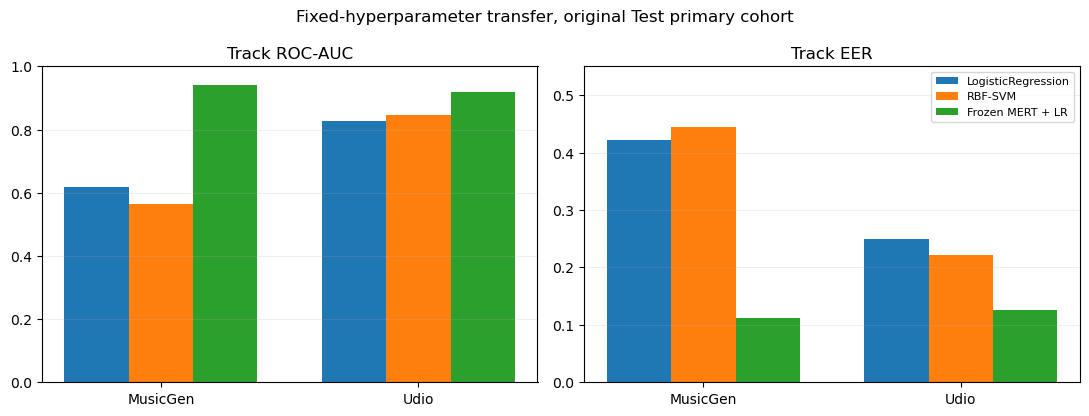

Saved: results/unseen_fixed_transfer_classical_mert/unseen_fixed_classical_mert_20260919T173138Z/primary_track_auc_eer.png


In [6]:
# 고정 설정 전이 세 모델의 Track AUC·EER을 대상별로 시각화한다.
track = primary.loc[primary.level.eq("track")]
models = ["LogisticRegression", "RBF-SVM", "Frozen MERT + LR"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(2)
width = 0.25
for i, model in enumerate(models):
    part = (
        track.loc[track.model.eq(model)]
        .set_index("holdout_generator")
        .loc[["musicgen", "udio"]]
    )
    axes[0].bar(x + (i - 1) * width, part["roc_auc"], width, label=model)
    axes[1].bar(x + (i - 1) * width, part["eer"], width, label=model)
for ax, title, top in zip(axes, ["Track ROC-AUC", "Track EER"], [1, 0.55]):
    ax.set_xticks(x, ["MusicGen", "Udio"])
    ax.set_ylim(0, top)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)
axes[1].legend(loc="upper right", fontsize=8)
fig.suptitle("Fixed-hyperparameter transfer, original Test primary cohort")
fig.tight_layout()
figure = RESULT / "primary_track_auc_eer.png"
fig.savefig(figure, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", figure.relative_to(ROOT))

그림에서 MusicGen의 MERT Track AUC/EER은 0.9407/0.1111, Udio는 0.9181/0.1250이다. 두 대상에서 MERT의 AUC가 가장 높고 EER이 가장 낮다.

대상별 동일 primary Test cohort 안에서 모델 차이를 간결하게 보여준다.

막대에는 불확실성 구간이 없고 대상 간 원곡 대응과 클래스 구성이 달라 난이도 순위를 말할 수 없다.

## 5. Udio 원곡 대응 보조 분석

Udio FAKE와 같은 원곡 24개에 REAL도 제한하면 REAL 24·FAKE 48 Track이다. 표본과 클래스 구성 모두 primary와 달라 모델·임계값 선택이나 primary 결론을 바꾸지 않는다. MusicGen paired-source 집합은 primary와 동일하다.

In [7]:
# Udio 대응 원곡 보조 분석을 Primary 결과와 분리해 표시한다.
print("Udio paired-source Test Track:")
display(
    paired.loc[paired.holdout_generator.eq("udio") & paired.level.eq("track"), columns]
    .round(4)
    .reset_index(drop=True)
)

Udio paired-source Test Track:

,holdout_generator,model,n_real,n_fake,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter
0,udio,LogisticRegression,24,48,0.8125,0.8889,0.6778,0.2500,0.6979,0.6495,0.1667,0.4375,0.3021
1,udio,RBF-SVM,24,48,0.8438,0.9064,0.7620,0.2083,0.7083,0.6511,0.1250,0.4583,0.2917
2,udio,Frozen MERT + LR,24,48,0.9201,0.9500,0.8779,0.1250,0.8125,0.7714,0.0833,0.2917,0.1875


Udio paired-source Track은 REAL24/FAKE48개이며 AUC/EER은 LR 0.8125/0.2500, SVM 0.8438/0.2083, MERT 0.9201/0.1250이다.

REAL을 대응 원곡 24개로 제한해도 세 모델 중 MERT의 순위 지표가 가장 높았다.

작고 불균형한 보조 cohort이며 primary와 REAL 표본이 다르다. 이 차이를 모델의 성능 변화로 단정하지 않는다.

## 6. 재현 확인과 해석 한계

Main 하이퍼파라미터를 고를 때 MusicGen/Udio가 Validation에 있었다. 두 생성기와 원래 Test도 과거 분석에서 이미 노출되었다. 따라서 이번 분석은 **고정 하이퍼파라미터 전이**이며 완전히 미노출인 모델 선택의 추정치가 아니다. MERT 외부 사전학습 데이터와 이 데이터의 중복 여부는 확인되지 않았다. FMA REAL과 생성기 FAKE의 출처·장르 차이, REAL Test 45 Track의 작은 수, Udio 원곡 대응 불균형도 일반화 해석을 제한한다.

아래 읽기 전용 검증은 원래 manifest와의 Test ID·라벨 일치, filtered Train scaler 평균, Main 고정 설정, Validation threshold 재계산, Track 평균, Segment·Track primary/paired 지표 전부를 다시 계산한다. Raw 점수·threshold·checkpoint hash는 이번 run 결과 폴더에 있다.

In [8]:
# 원점수·임계값·필터 mask를 독립 검증기로 재계산한다.
import subprocess, sys

check = subprocess.run(
    [sys.executable, "-m", "scripts.verify_unseen_fixed_transfer"],
    cwd=ROOT,
    text=True,
    capture_output=True,
    check=True,
)
print(check.stdout.strip())

PASS unseen_fixed_classical_mert_20260919T173138Z: six fresh fixed fits, filtered scalers, Val thresholds, 24 Test metric rows


읽기 전용 검증이 `PASS`였다. 6개 fresh fit의 filtered Train scaler 평균, Val 임계값, primary/paired Segment·Track 24개 지표 행이 재계산됐다.

저장된 설정과 점수·라벨·cohort·지표가 같은 고정 설정 전이 run을 가리킨다.

내부 일관성 검증은 Main 하이퍼파라미터 선택 때의 대상 노출과 원래 Test의 과거 공개를 없애지 않는다.